## **The Markov Blanket : a roadmap toward feature selection with causality**

This notebook builds on the **light tunnel** Causal Chamber of Gamella, Peters & Bühlmann (2024).

It uses a **synthetic stand-in dataset**, generated from a
hand-built structural causal model (SCM) designed to mirror the light tunnel's actual physical
structure as described in the paper: a light source (R, G, B) feeds a first sensor (V1, I1);
auxiliary LEDs (L11, L12) contribute weakly and non-linearly there; a first polarizer (theta1)
attenuates the signal reaching a second sensor (V2, I2), with more LEDs (L21, L22) added; a
second polarizer (theta2) attenuates the signal reaching a third sensor (V3, I3), with LEDs
(L31, L32) added there. We also include a nuisance variable `Z_V1` (standing in for the real
system's sensor exposure time) that affects `V1` but **not** `I1` — used later to reproduce the
report's finding that a model relying on a merely-correlated predictor can be broken by an
intervention the causal predictors never see.

In [1]:
!pip install -q --break-system-packages scikit-learn networkx scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations
from sklearn.linear_model import LinearRegression

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 100

## **Data generation**

In [3]:
def sample_environment(n, rng, intervene=None):
    """Draw n samples from the light-tunnel SCM. `intervene` optionally overrides one
    variable's sampling range -- this is how we simulate the report's single-target
    interventions (Table 1: e.g. 'uniform_red_mid' shifts R's marginal only)."""
    intervene = intervene or {}

    def u(name, lo, hi):
        if name in intervene:
            lo, hi = intervene[name]
        return rng.uniform(lo, hi, n)

    R = u('R', 0, 85); G = u('G', 0, 85); B = u('B', 0, 85)
    L11 = u('L11', 0, 170); L12 = u('L12', 0, 170)
    L21 = u('L21', 0, 170); L22 = u('L22', 0, 170)
    L31 = u('L31', 0, 170); L32 = u('L32', 0, 170)
    theta1 = u('theta1', -15, 25); theta2 = u('theta2', -15, 25)
    Z_V1 = u('Z_V1', 0.8, 1.2)
    noise = lambda scale: rng.normal(0, scale, n)

    I1 = 12*R + 6*G + 3*B + 0.02*np.exp(L11/60) + 0.02*np.exp(L12/60) + noise(60)
    V1 = 9*R + 10*G + 2*B + Z_V1*180 + noise(60)

    atten1 = 0.5 + 0.5*np.cos(np.deg2rad(2*theta1))
    I2 = 0.9*I1*atten1 + 0.05*L21 + 0.05*L22 + noise(50)
    V2 = 0.9*V1*atten1 + 0.05*L21 + 0.05*L22 + noise(50)

    atten2 = 0.5 + 0.5*np.cos(np.deg2rad(2*theta2))
    I3 = 0.9*I2*atten2 + 0.05*L31 + 0.05*L32 + noise(45)
    V3 = 0.9*V2*atten2 + 0.05*L31 + 0.05*L32 + noise(45)

    return pd.DataFrame({
        'R': R, 'G': G, 'B': B, 'L11': L11, 'L12': L12, 'L21': L21, 'L22': L22,
        'L31': L31, 'L32': L32, 'theta1': theta1, 'theta2': theta2, 'Z_V1': Z_V1,
        'V1': V1, 'V2': V2, 'V3': V3, 'I1': I1, 'I2': I2, 'I3': I3,
    })

In [4]:
TRUE_PARENTS = {
    'I1': {'R', 'G', 'B', 'L11', 'L12'},
    'V1': {'R', 'G', 'B', 'Z_V1'},
    'I2': {'I1', 'theta1', 'L21', 'L22'},
    'V2': {'V1', 'theta1', 'L21', 'L22'},
    'I3': {'I2', 'theta2', 'L31', 'L32'},
    'V3': {'V2', 'theta2', 'L31', 'L32'},
}
TRUE_EDGES = {frozenset({p, c}) for c, ps in TRUE_PARENTS.items() for p in ps}

rng_master = np.random.default_rng(0)
df_ref = sample_environment(3000, rng_master)
print(f"Reference environment: {df_ref.shape[0]} samples, {df_ref.shape[1]} variables")
df_ref.describe().T[['mean', 'std']].round(2)

Reference environment: 3000 samples, 18 variables


,mean,std
R,42.30,24.59
G,42.48,24.53
B,42.40,24.69
L11,85.54,48.89
L12,86.53,48.79
L21,85.12,48.55
L22,86.94,48.30
L31,83.78,48.44
L32,84.89,49.18
theta1,4.93,11.58


## **The Markov Blanket: concept, toy example, and ground truth**

## **Definition**



For a target variable $Y$ in a DAG $G$ over variables $V$, the **Markov blanket** $MB(Y)$ is the
*minimal* subset of $V \setminus \{Y\}$ such that

$$P(Y \mid V \setminus \{Y\}) = P(Y \mid MB(Y)).$$

In words: once you know $MB(Y)$, learning the value of *any other* variable in the system tells
you nothing more about $Y$. In a DAG, this minimal set has an exact graphical characterization:

$$MB(Y) = \text{Parents}(Y) \;\cup\; \text{Children}(Y) \;\cup\; \text{Spouses}(Y)$$

where **spouses** (co-parents) are the *other* parents of $Y$'s children.

Why does the blanket need children's co-parents and not, say, grandparents? Because a child $C$
of $Y$ is a **collider**: conditioning on $C$ *opens* a path between $Y$ and $C$'s other parents
(this is the "explaining away" effect). So once you condition on children, their co-parents
become newly informative about $Y$ and must be included too. Parents' parents, on the other
hand, only reach $Y$ through $Y$'s parents, who are already in the blanket — no new information.

## **We consider a toy model**

In [5]:
# Toy graph: A -> Y -> B <- C
G_toy = nx.DiGraph()
G_toy.add_edges_from([('A', 'Y'), ('Y', 'B'), ('C', 'B')])

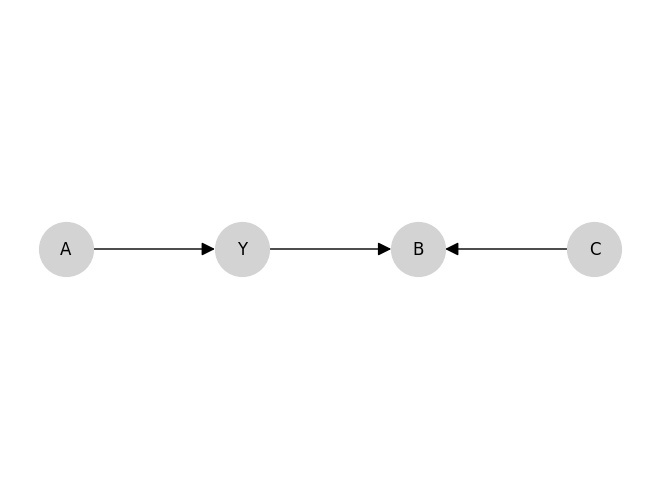

In [6]:
pos = {'A': (0, 0), 'Y': (1, 0), 'B': (2, 0), 'C': (3, 0)}
nx.draw(G_toy, pos, with_labels=True, node_size=1500,
        node_color='lightgray', arrowsize=20)
plt.show()

## **Calculation of the Markov Blanket of $Y$ on this toy model. Precise parents, children and spouses**

In [7]:
def markov_blanket(G, y):
    parents = set(G.predecessors(y))
    children = set(G.successors(y))
    spouses = set()
    for c in children:
        spouses |= set(G.predecessors(c)) - {y}
    return parents | children | spouses

In [8]:
print("Parents(Y):", set(G_toy.predecessors('Y')))
print("Children(Y):", set(G_toy.successors('Y')))
print("MB(Y):", markov_blanket(G_toy, 'Y'))

Parents(Y): {'A'}
Children(Y): {'B'}
MB(Y): {'B', 'A', 'C'}


**Comment:** $MB(Y) = \{A, B, C\}$. The node $C$ *is* in the blanket, even though $C$ has no direct
causal link to $Y$ at all! This is exactly the collider effect described above: once you know
$B$ (a common effect of $Y$ and $C$), $C$ becomes informative about $Y$ (if $B$ is high and $C$
is low, $Y$ was probably high).

## **Question 1 : Compute the true $MB(\tilde I_1)$ for our synthetic system**

We build a `networkx` DiGraph from `TRUE_PARENTS` and read off the blanket mechanically, exactly
as in the toy example above.

In [9]:
G_true = nx.DiGraph()
G_true.add_nodes_from(set(TRUE_PARENTS.keys()) | set().union(*TRUE_PARENTS.values()))
for child, parents in TRUE_PARENTS.items():
    for p in parents:
        G_true.add_edge(p, child)

In [10]:
MB_I1_true = markov_blanket(G_true, 'I1')
print("Parents(I1):  ", set(G_true.predecessors('I1')))
print("Children(I1): ", set(G_true.successors('I1')))
print("Spouses(I1):  ", markov_blanket(G_true, 'I1') - set(G_true.predecessors('I1')) - set(G_true.successors('I1')))
print()
print("MB(I1) in THIS synthetic dataset:", sorted(MB_I1_true))


Parents(I1):   {'L11', 'G', 'L12', 'B', 'R'}
Children(I1):  {'I2'}
Spouses(I1):   {'L21', 'theta1', 'L22'}

MB(I1) in THIS synthetic dataset: ['B', 'G', 'I2', 'L11', 'L12', 'L21', 'L22', 'R', 'theta1']


## **Question 2 : Grow-Shrink: a local algorithm for Markov blanket discovery**

We tested two *global* algorithms (PC, GES) that
reconstruct the **entire** DAG, from which $MB(\tilde I_1)$ can then be read off. So why bother
with a second, local-only method?

Two reasons :

1. **Error isolation.** A mistake made by a global algorithm on some *unrelated* part of the
   graph (say, an edge between `theta2` and `L31`) can corrupt the orientation of edges
   elsewhere through cascading rules (recall PC's R1–R4 orientation rules from the reproduction
   notebook — one wrong collider can misorient a chain of downstream edges). A local method
   that only ever asks "is $Y$ independent of variable $Z$ given some conditioning set?" for
   variables *near* $Y$ never has that failure mode.
2. **We don't need the whole graph.** if our goal is the prediction of
   $\tilde I_1$. The Markov blanket is *exactly* the minimal, sufficient covariate set for that recovering the rest of the DAG is wasted effort

## **The algorithm (Grow-Shrink, Margaritis 2003)**

Grow-Shrink has two phases, and it's genuinely simple to state:

- **Growing phase:** start from an empty set $\hat S = \emptyset$. Repeatedly scan all
  variables not yet in $\hat S$; if you find one that is *dependent* on the target given
  $\hat S$, add it. Stop when no such variable remains.
- **Shrinking phase:** now that $\hat S$ is a (possibly bloated) superset of the true blanket,
  remove any variable $Y' \in \hat S$ that turns out to be *conditionally independent* of the
  target given the *rest* of $\hat S$ — i.e. it was only useful because of variables that have
  since joined the set, not because it's really in the blanket.

The growing phase can add spurious variables (order-dependent — an early "lucky" association
that gets explained away later); the shrinking phase is what cleans this up.

## **Conditional independence testing: partial correlation + Fisher's Z**

We shall use tests valid in a **linear Gaussian** setting
so we can test $X \perp Y \mid S$ using the **partial correlation** $\rho_{XY \mid S}$: the
correlation between $X$ and $Y$ after removing the linear effect of $S$ from both (equivalently,
the correlation between the residuals of $X \sim S$ and $Y \sim S$).

We implement this directly below.

In [11]:
from scipy import stats

def partial_corr(data, x, y, Z):
    '''Partial correlation of x, y given the set Z, via residuals of linear regression.'''
    if len(Z) == 0:
        return np.corrcoef(data[x], data[y])[0, 1]
    Zmat = data[list(Z)].values
    def resid(v):
        beta, *_ = np.linalg.lstsq(np.column_stack([np.ones(len(Zmat)), Zmat]), data[v].values, rcond=None)
        return data[v].values - np.column_stack([np.ones(len(Zmat)), Zmat]) @ beta
    rx, ry = resid(x), resid(y)
    return np.corrcoef(rx, ry)[0, 1]

def fisher_z_test(data, x, y, Z, alpha=0.05):
    '''Fisher's Z conditional-independence test (report's Eq. 3).
    Returns True if we FAIL to reject independence (i.e. we declare X _|_ Y | Z).'''
    n = len(data)
    rho = partial_corr(data, x, y, Z)
    rho = np.clip(rho, -0.999999, 0.999999)  # numerical guard
    k = len(Z)
    if n - k - 3 <= 0:
        return True  # not enough samples to test -- conservatively call independent
    z_stat = 0.5 * np.sqrt(n - k - 3) * np.log((1 + rho) / (1 - rho))
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    return p_value > alpha  # True = independent (fail to reject H0)

In [12]:
# Simulate the toy graph with linear-Gaussian mechanisms to check our CI test against known truth
rng_toy = np.random.default_rng(12)
n_toy = 3000
A = rng_toy.normal(size=n_toy)
C = rng_toy.normal(size=n_toy)
Y = 1.5 * A + rng_toy.normal(scale=0.5, size=n_toy)
B = 1.2 * Y + 1.2 * C + rng_toy.normal(scale=0.5, size=n_toy)
toy_df = pd.DataFrame({'A': A, 'Y': Y, 'B': B, 'C': C})

print("Y _|_ C | {}   ->", "INDEPENDENT" if fisher_z_test(toy_df, 'Y', 'C', []) else "DEPENDENT",
      " (expected: INDEPENDENT -- no common cause, no direct edge)")
print("Y _|_ C | {B}  ->", "INDEPENDENT" if fisher_z_test(toy_df, 'Y', 'C', ['B']) else "DEPENDENT",
      " (expected: DEPENDENT -- conditioning on collider B opens the path)")

Y _|_ C | {}   -> INDEPENDENT  (expected: INDEPENDENT -- no common cause, no direct edge)
Y _|_ C | {B}  -> DEPENDENT  (expected: DEPENDENT -- conditioning on collider B opens the path)


This confirms the collider ("explaining away") effect empirically: $Y$ and $C$ look unrelated
until you condition on their shared child $B$, at which point they become dependent — exactly
the mechanism that puts spouses inside the Markov blanket.

## **Grow-Shrink implementation**

In [13]:
def grow_shrink(data, target, candidates, alpha=0.05, verbose=False):
    '''Algorithm 2 from the report: Grow-Shrink Markov blanket estimation.'''
    S = []
    # --- Growing phase ---
    changed = True
    while changed:
        changed = False
        for var in candidates:
            if var in S or var == target:
                continue
            independent = fisher_z_test(data, target, var, S, alpha=alpha)
            if not independent:  # dependent given current S -> grow
                S.append(var)
                changed = True
                if verbose:
                    print(f"  [grow]   added {var:10s} -> S = {S}")
    # --- Shrinking phase ---
    for var in list(S):
        S_minus = [v for v in S if v != var]
        independent = fisher_z_test(data, target, var, S_minus, alpha=alpha)
        if independent:  # redundant given the rest -> shrink
            S.remove(var)
            if verbose:
                print(f"  [shrink] removed {var:10s} -> S = {S}")
    return set(S)

## **Question 2a : Test this algorithm on the toy graph**

Running GS on our toy dataset should recover exactly $MB(Y) = \{A, B, C\}$

In [14]:
mb_toy = grow_shrink(toy_df, 'Y', ['A', 'B', 'C'], alpha=0.05, verbose=True)
print("\nEstimated MB(Y):", mb_toy, " | True MB(Y):", {'A', 'B', 'C'})

  [grow]   added A          -> S = ['A']
  [grow]   added B          -> S = ['A', 'B']
  [grow]   added C          -> S = ['A', 'B', 'C']

Estimated MB(Y): {'B', 'A', 'C'}  | True MB(Y): {'B', 'A', 'C'}


## **Question 2b : Apply Grow-Shrink to the light tunnel, with bootstrap aggregation**

A single run of GS on one dataset can be unstable — the growing phase's outcome depends on scan
order and on which spurious associations happen to look significant in that particular sample.
The report's fix (and ours) is **bootstrap aggregation (bagging)**: resample the dataset with
replacement 100 times, run GS on each resample, and report *how often* each variable is included
across the 100 runs. A variable that's "really" in the blanket should show up almost every time;
a spurious one will appear inconsistently.

In [15]:
candidate_vars = ['R','G','B','L11','L12','L21','L22','L31','L32','theta1','theta2','V1','V2','V3','I2','I3']

rng_boot = np.random.default_rng(7)
n_boot = 100
counts = {v: 0 for v in candidate_vars}

for b in range(n_boot):
    idx = rng_boot.integers(0, len(df_ref), size=len(df_ref))
    boot_df = df_ref.iloc[idx].reset_index(drop=True)
    mb_b = grow_shrink(boot_df, 'I1', candidate_vars, alpha=0.05)
    for v in mb_b:
        counts[v] += 1

freq = pd.Series(counts).sort_values(ascending=False) / n_boot
freq_table = freq[freq > 0.05]
freq_table.to_frame('frequency').round(2)

,frequency
R,1.00
G,1.00
B,1.00
theta1,1.00
V2,1.00
I2,1.00
V1,1.00
L31,0.39
V3,0.30
L11,0.26


We isolate variables whose bootstrap frequency clears a threshold (here
uses 0.80). Everything above the elbow is kept as the estimated Markov blanket.

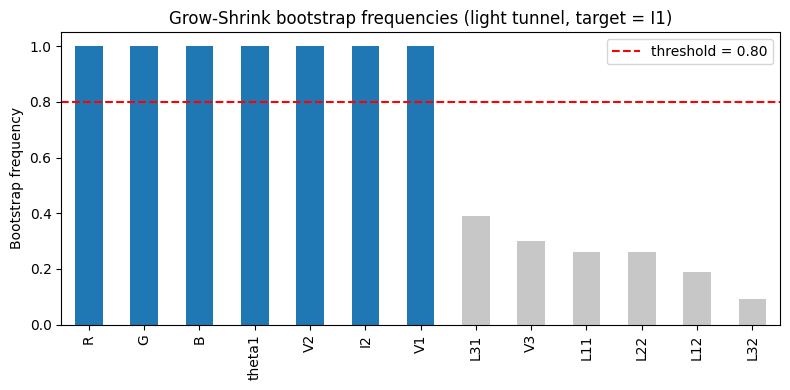

Estimated MB(I1) via Grow-Shrink + bagging: {'G', 'V1', 'theta1', 'B', 'I2', 'V2', 'R'}


In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
freq_table.plot(kind='bar', ax=ax, color=['#1f77b4' if f >= 0.80 else '#c7c7c7' for f in freq_table])
ax.axhline(0.80, color='red', linestyle='--', label='threshold = 0.80')
ax.set_ylabel('Bootstrap frequency')
ax.set_title('Grow-Shrink bootstrap frequencies (light tunnel, target = I1)')
ax.legend()
plt.tight_layout()
plt.show()

MB_GS_estimated = set(freq_table[freq_table >= 0.80].index)
print("Estimated MB(I1) via Grow-Shrink + bagging:", MB_GS_estimated)

## **Scoring against ground truth**

Recall that the *honest* ground truth Markov blanket in **this synthetic dataset**
is $MB(\tilde I_1) = \{R, G, B, L_{11}, L_{12}\} \cup \{I_2\} \cup \{\theta_1, L_{21}, L_{22}\}$
— parents, plus a child, plus that child's co-parents. We score precision/recall/F1 exactly as
in the reproduction notebook.

## **Question 3 : Stability across environments**

The next cell needs several environments, each generated by a single-target intervention that shifts the marginal of one variable. We define them here, then check for each candidate subset how much its regression coefficients vary from one environment to another. A subset whose coefficients stay stable across environments is a good, invariant predictor of $\tilde I_1$.

## **Sample environnements**

In [17]:
intervention_specs = {
    'reference':        None,
    'uniform_red_mid':  {'R': (30, 55)},
    'uniform_red_high': {'R': (55, 85)},
    'uniform_green_mid':{'G': (30, 55)},
    'uniform_blue_mid': {'B': (30, 55)},
    'theta1_shift':     {'theta1': (5, 25)},
    'Z_V1_shift':       {'Z_V1': (1.2, 1.6)},
    'L21_L22_shift':    {'L21': (100, 170), 'L22': (100, 170)},
}

rng_env = np.random.default_rng(42)
environments = {name: sample_environment(3000, rng_env, intervene=spec)
                for name, spec in intervention_specs.items()}
print(f"{len(environments)} environments:", list(environments))

8 environments: ['reference', 'uniform_red_mid', 'uniform_red_high', 'uniform_green_mid', 'uniform_blue_mid', 'theta1_shift', 'Z_V1_shift', 'L21_L22_shift']


## **Subsets of explicative variables on which we are going to regress**

In [18]:
stability_subsets = {
    "S'1: {R}":                    ['R'],
    "S'2: {R,G}":                  ['R', 'G'],
    "S'3: {R,B}":                  ['R', 'B'],
    "S'4: {R,G,B} = MB_lin":       ['R', 'G', 'B'],
    "S'5: {R,G,B,V1}":             ['R', 'G', 'B', 'V1'],
    "S'6: {R,G,B,V1,V2}":          ['R', 'G', 'B', 'V1', 'V2'],
    "S'7: {R,G,B,V1,V2,V3}":       ['R', 'G', 'B', 'V1', 'V2', 'V3'],
    "S'8: {R,G,B,I2,I3}":          ['R', 'G', 'B', 'I2', 'I3'],
}

## **Question 3a : Retrain separtely linear regression in each environment for a given subset of explicative variables**

In [19]:
def stability_score(subset_vars):
    coefs_per_env = []
    for env_name, env_df in environments.items():
        X = env_df[subset_vars].values
        y = env_df['I1'].values
        model = LinearRegression().fit(X, y)
        coefs_per_env.append(model.coef_)
    coefs_per_env = np.array(coefs_per_env)          # shape (n_envs, n_vars)
    var_per_coef = coefs_per_env.var(axis=0)          # variance across environments, per variable
    return var_per_coef.mean(), coefs_per_env


## **Question 3b : Test the stability of regression on each environment for each subset of variables $S$**

In [20]:
stab_values = {}
coefs_by_subset = {}
for name, s in stability_subsets.items():
  stab, coefs = stability_score(s)
  stab_values[name] = stab
  coefs_by_subset[name] = coefs

In [21]:
pd.Series(stab_values).round(4).to_frame('Stab(S)')

,Stab(S)
S'1: {R},0.0107
"S'2: {R,G}",0.0187
"S'3: {R,B}",0.0130
"S'4: {R,G,B} = MB_lin",0.0073
"S'5: {R,G,B,V1}",0.0131
"S'6: {R,G,B,V1,V2}",0.0105
"S'7: {R,G,B,V1,V2,V3}",0.0088
"S'8: {R,G,B,I2,I3}",0.0109


In [22]:
coefs_by_subset

{"S'1: {R}": array([[12.1404],
        [12.0511],
        [11.9959],
        [11.9952],
        [11.8771],
        [12.1645],
        [11.9097],
        [11.8854]]),
 "S'2: {R,G}": array([[11.966 ,  6.0946],
        [12.3359,  5.99  ],
        [11.7219,  5.9586],
        [11.9367,  5.7759],
        [12.1432,  6.0446],
        [11.9806,  6.0489],
        [11.8653,  5.964 ],
        [11.9782,  5.9971]]),
 "S'3: {R,B}": array([[12.2196,  3.0883],
        [12.0195,  3.0344],
        [12.1507,  2.7931],
        [12.0417,  2.9871],
        [11.8507,  3.1479],
        [12.1527,  3.1143],
        [11.9503,  2.9347],
        [11.9368,  2.9319]]),
 "S'4: {R,G,B} = MB_lin": array([[12.0443,  6.0558,  3.0111],
        [12.3035,  5.9624,  2.9772],
        [11.8793,  5.9984,  2.8743],
        [11.9815,  6.0004,  3.0244],
        [12.1188,  6.0316,  2.8298],
        [11.9702,  6.0131,  3.0459],
        [11.9063,  5.983 ,  2.9725],
        [12.0318,  6.0407,  3.0221]]),
 "S'5: {R,G,B,V1}": array([[11.

## **Question 4 : Predicting $\tilde I_1$ with all variables vs. the Markov blanket**

The point of the Markov blanket is that it is a *sufficient* covariate set: $P(I_1 \mid V\setminus\{I_1\}) = P(I_1 \mid MB(I_1))$. So in principle a model that only sees $MB(I_1)$ should predict as well as one that sees every variable, with fewer features to estimate.

We compare three feature sets for predicting $\tilde I_1$:

- **All variables**: the 16 candidate variables.
- **MB (Grow-Shrink)**: the blanket estimated by Grow-Shrink + bagging above.
- **MB (true)**: the ground-truth blanket read off the DAG (a reference).



In [23]:
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor

ALL_FEATS  = list(candidate_vars)
GS_FEATS   = sorted(MB_GS_estimated)
TRUE_FEATS = sorted(MB_I1_true)

# **Question 4a : display the list of features corresponding to each set**

In [24]:
FEATURE_SETS = {'All variables': ALL_FEATS, 'MB (Grow-Shrink)': GS_FEATS, 'MB (true)': TRUE_FEATS}
for name, f in FEATURE_SETS.items():
    print(f"{name:18s} ({len(f):2d} features): {f}")

print()
print("In GS estimate but not in true MB:", sorted(set(GS_FEATS) - set(TRUE_FEATS)))
print("In true MB but missed by GS      :", sorted(set(TRUE_FEATS) - set(GS_FEATS)))

All variables      (16 features): ['R', 'G', 'B', 'L11', 'L12', 'L21', 'L22', 'L31', 'L32', 'theta1', 'theta2', 'V1', 'V2', 'V3', 'I2', 'I3']
MB (Grow-Shrink)   ( 7 features): ['B', 'G', 'I2', 'R', 'V1', 'V2', 'theta1']
MB (true)          ( 9 features): ['B', 'G', 'I2', 'L11', 'L12', 'L21', 'L22', 'R', 'theta1']

In GS estimate but not in true MB: ['V1', 'V2']
In true MB but missed by GS      : ['L11', 'L12', 'L21', 'L22']


Note that the estimated blanket is not identical to the true one: Grow-Shrink keeps `V1`/`V2` (which are only correlated with $I_1$ through $R,G,B$) and misses the weak effects of `L11`, `L12`, `L21`, `L22`. That is why the true blanket is included as a reference: it separates the value of the *concept* from the quality of our *estimate*.

Two questions:

1. **In-distribution:** does dropping the non-blanket variables cost accuracy? (We expect no, and a gain when training data is scarce.)
2. **Under distribution shift:** if variables *outside* the blanket change their distribution at test time, is the blanket model more robust?

We use a linear regression and a gradient-boosting model, because the linear model can hide differences that a flexible model reveals.

## **Question 4b : In-distribution prediction (learning curve)**

Train on datasets of increasing size and evaluate on one fixed, large test set drawn from the same environment. Each point is averaged over 20 random training sets.

In [25]:
def make_model(kind):
    return LinearRegression() if kind == 'linear' else HistGradientBoostingRegressor(max_iter=150, random_state=0)

def rmse(y, yhat):
    return np.sqrt(mean_squared_error(y, yhat))

def fit_eval(train_df, test_df, feats, kind='linear'):
    m = make_model(kind).fit(train_df[feats].values, train_df['I1'].values)
    return rmse(test_df['I1'].values, m.predict(test_df[feats].values))

In [26]:
rng_pred = np.random.default_rng(100)
test_iid = sample_environment(5000, rng_pred)
train_sizes = [30, 50, 100, 300, 1000, 3000]

In [ ]:
rows = []
for kind in ['linear', 'boosting']:
    for n_train in train_sizes:
        for rep in range(20):
            tr = sample_environment(n_train, rng_pred)
            for name, feats in FEATURE_SETS.items():
                rows.append((kind, n_train, name, fit_eval(tr, test_iid, feats, kind)))
res_iid = pd.DataFrame(rows, columns=['model', 'n_train', 'features', 'rmse'])

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, kind in zip(axes, ['linear', 'boosting']):
    sub = res_iid[res_iid.model == kind].groupby(['n_train', 'features'])['rmse'].mean().unstack('features')
    sub[list(FEATURE_SETS)].plot(ax=ax, marker='o')
    ax.set_xscale('log'); ax.set_title(f'{kind} model'); ax.set_xlabel('training set size'); ax.set_ylabel('test RMSE')
plt.suptitle('Predicting I1: in-distribution test error')
plt.tight_layout(); plt.show()

res_iid.groupby(['model', 'n_train', 'features'])['rmse'].mean().unstack('features')[list(FEATURE_SETS)].round(1)

**Reading the curve.** With plenty of data the three feature sets give almost the same error: the extra variables carry no additional information about $I_1$, exactly as the blanket property predicts. The gap opens when the training set is small, because the model with 16 features has more coefficients to estimate from few samples (higher variance), while the blanket model has fewer. The gap is largest for the linear model at the smallest sizes. (At n=30 the boosting model has too few samples to split and returns nearly the same constant prediction for every feature set, so its curve starts at n=50.) One subtlety: with lots of data the *true* blanket is about 1 RMSE unit worse than the other linear models. The mechanism $I_2 \propto I_1 \cdot \text{atten}(\theta_1)$ is multiplicative, which a linear model cannot capture, and the non-blanket `V1`/`V2` happen to serve as linear proxies. The blanket property holds for the true conditional distribution, not for a misspecified model.

## **Question 4c : Prediction under distribution shift**

Now train once on the reference environment and test on environments where a variable **outside** the blanket has a different distribution, using the `intervene` argument of `sample_environment`. Some shifts push the variable beyond its training range, so a model that leans on it has to extrapolate.

- `Z_V1 shifted`: the hidden factor behind `V1` (a non-blanket variable) moves.
- `theta2 shifted`: the second polarizer angle moves.
- `L31, L32 shifted`: the ambient light terms behind `I3`/`V3` move.
- `all combined`: all of the above at once.

In [ ]:
shift_envs = {
    'no shift':         None,
    'Z_V1 shifted':     {'Z_V1': (2.5, 4.0)},
    'theta2 shifted':   {'theta2': (30, 45)},
    'L31, L32 shifted': {'L31': (300, 400), 'L32': (300, 400)},
    'all combined':     {'Z_V1': (2.5, 4.0), 'theta2': (30, 45), 'L31': (300, 400), 'L32': (300, 400)},
}

train_ood = sample_environment(3000, np.random.default_rng(200))

In [ ]:
rows = []
for env_name, interv in shift_envs.items():
    te = sample_environment(5000, np.random.default_rng(300), intervene=interv)
    for kind in ['linear', 'boosting']:
        for name, feats in FEATURE_SETS.items():
            rows.append((env_name, kind, name, fit_eval(train_ood, te, feats, kind)))
res_ood = pd.DataFrame(rows, columns=['environment', 'model', 'features', 'rmse'])

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, kind in zip(axes, ['linear', 'boosting']):
    sub = res_ood[res_ood.model == kind].pivot(index='environment', columns='features', values='rmse')
    sub = sub.loc[list(shift_envs), list(FEATURE_SETS)]
    sub.plot(kind='bar', ax=ax, rot=30)
    ax.set_title(f'{kind} model'); ax.set_ylabel('test RMSE'); ax.set_xlabel('')
plt.suptitle('Predicting I1: test error when non-blanket variables shift')
plt.tight_layout(); plt.show()

res_ood.pivot_table(index=['model', 'environment'], columns='features', values='rmse', sort=False)[list(FEATURE_SETS)].round(1)

## **Conclusions**

- **Accuracy is essentially preserved.** With enough data, the blanket models predict $I_1$ about as well as the model using all 16 variables (within about one RMSE unit for the linear model, and slightly better or equal for boosting): the other variables add almost nothing once $MB(I_1)$ is known.
- **Fewer features help when data is scarce.** The reduced feature set lowers variance in small samples, most visibly for the linear model.
- **Robustness depends on the model and on the quality of the blanket.** The linear model is barely affected by the shifts, because the coefficients it puts on non-blanket variables are close to zero. The flexible model does use non-blanket variables, and its error grows when they shift. The true blanket is essentially unaffected, while the Grow-Shrink blanket sits in between: it removed most of the non-blanket variables but kept `V1` and `V2`, which still expose it to the `Z_V1` shift.
- **Caveats.** The blanket is only sufficient for predicting $I_1$ under the *same* mechanism. If the mechanism linking $I_1$ to a blanket member changes (an intervention on $I_1$'s own mechanism, or on the $I_1 \to I_2$ link), the blanket model is not protected either. Also, the quality of the result relies on the quality of the estimated blanket, which is limited by the power of the conditional independence tests.